# Surrogate Model Evaluation

We will modify the parameters for SingleTaskGP to find the one that best fits our benchmark (LABS)

In [ ]:
# Visualization

import matplotlib.pyplot as plt
import torch

def cv_plot(q_middle, q_lower, q_upper, Y_true, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    min_val = (torch.minimum(Y_true, q_lower)).min()
    max_val = (torch.maximum(Y_true, q_upper)).max()
    min_val, max_val = min_val - 0.1 * (max_val - min_val), max_val + 0.1 * (max_val - min_val)
    ax.plot([min_val, max_val], [min_val, max_val], "b--", lw=2)

    yerr1, yerr2 = q_middle - q_lower, q_upper - q_middle
    yerr = torch.cat((yerr1.unsqueeze(0), yerr2.unsqueeze(0)), dim=0).squeeze(-1)
    markers, caps, bars = ax.errorbar(
        Y_true.cpu().numpy(),
        q_middle.cpu().numpy(),
        yerr=yerr.cpu().numpy(),
        fmt=".",
        capsize=4,
        elinewidth=2.0,
        ms=14,
        c="k",
        ecolor="gray",
    )
    [bar.set_alpha(0.8) for bar in bars]
    [cap.set_alpha(0.8) for cap in caps]
    ax.set_xlim([min_val, max_val])
    ax.set_ylim([min_val, max_val])
#    ax.set_xlabel("True value", fontsize=24)
#    ax.set_ylabel("Predicted value", fontsize=24)
    ax.grid(True)

def cv_plots(gp_model, test_x, test_y):
    mean = gp_model.posterior(test_x).mean
    var = gp_model.posterior(test_x).variance
    mean = mean.detach().squeeze()
    var = var.detach().squeeze()
    q1 = mean - 1.96 * var.sqrt()
    q2 = mean + 1.96 * var.sqrt()
    cv_plot(q_middle=mean, q_lower=q1, q_upper=q2, Y_true = test_y)
    plt.xlabel("Ground Truth")
    plt.ylabel("Predictions")


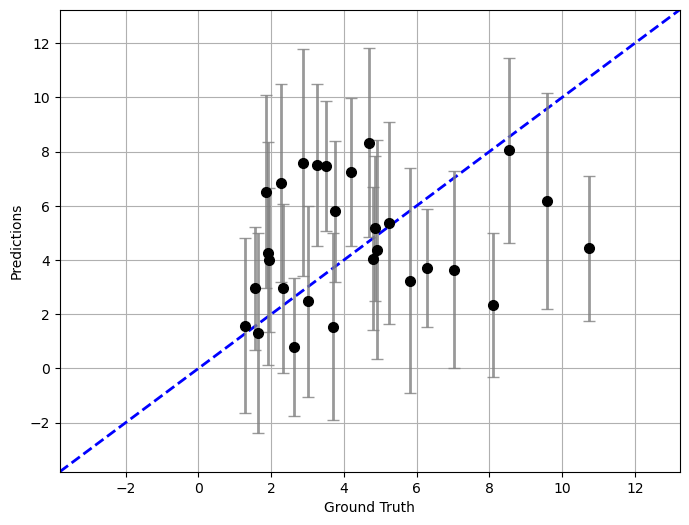

In [ ]:
# Default GP run - RBF Kernel

import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.utils.sampling import draw_sobol_samples
from botorch.models.transforms.input import Normalize

# LABS Objective
def labs_merit(x):
    total = 0
    for k in range(1, len(x)):
        a_k = torch.sum((2 * x[:-k] - 1) * (2 * x[k:] - 1))
        total += a_k ** 2
    return total.item()

def sample(n, num_points):
    x = torch.rand(num_points, n)
    y = torch.tensor([[labs_merit(xi)] for xi in x])
    return x, y

n = 10
train_x, train_y = sample(n, 28)
test_x, test_y = sample(n, 28)

train_x = train_x.double()
train_y = train_y.double()
test_x = test_x.double()
test_y = test_y.double()

y_mean = train_y.mean()
y_std = train_y.std()
train_y_norm = (train_y - y_mean) / y_std

model = SingleTaskGP(train_x, train_y, input_transform=Normalize(d=n))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

cv_plots(model, test_x, test_y)


In [3]:
model.__dict__

{'_num_outputs': 1,
 '_input_batch_shape': torch.Size([]),
 '_aug_batch_shape': torch.Size([]),
 'training': False,
 '_parameters': OrderedDict(),
 '_buffers': OrderedDict(),
 '_non_persistent_buffers_set': set(),
 '_backward_pre_hooks': OrderedDict(),
 '_backward_hooks': OrderedDict(),
 '_is_full_backward_hook': None,
 '_forward_hooks': OrderedDict(),
 '_forward_hooks_with_kwargs': OrderedDict(),
 '_forward_hooks_always_called': OrderedDict(),
 '_forward_pre_hooks': OrderedDict(),
 '_forward_pre_hooks_with_kwargs': OrderedDict(),
 '_state_dict_hooks': OrderedDict(),
 '_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_pre_hooks': OrderedDict([(2,
               <torch.nn.modules.module._WrappedHook at 0x7faac82ef760>)]),
 '_load_state_dict_post_hooks': OrderedDict(),
 '_modules': OrderedDict([('likelihood',
               GaussianLikelihood(
                 (noise_covar): HomoskedasticNoise(
                   (noise_prior): LogNormalPrior()
                   (raw_noise_const

In [4]:
model.likelihood.noise

Parameter containing:
tensor([0.0062], dtype=torch.float64, requires_grad=True)

In [5]:
model.covar_module.lengthscale

Parameter containing:
tensor([[2.6049, 3.0151, 2.2533, 3.1309, 1.8030, 2.8294, 3.5162, 3.5249, 2.0083,
         2.6015, 0.6772, 0.5852, 2.9416, 2.4354, 0.8271, 0.7178, 3.3242, 1.8930,
         2.7586, 2.9572, 1.6486, 3.6828, 0.2217, 2.2491, 3.4420, 3.3593, 2.9726,
         1.3364, 3.1862, 2.5124, 0.5164, 0.3280, 3.1434, 2.3972, 2.6764, 2.5612,
         3.0945, 2.1853, 1.9480, 2.7075]], dtype=torch.float64,
       requires_grad=True)

In [ ]:
# Runs with available (and applicable) off the shelf Kernels in GPyTorch (https://docs.gpytorch.ai/en/stable/kernels.html)

import torch
import gpytorch.kernels as kernels
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood

def labs_merit(x):
    total = 0
    for k in range(1, len(x)):
        total += (torch.sum((2*x[:-k]-1)*(2*x[k:]-1)) ** 2)
    return total.item()

def sample(n, pts):
    X = torch.rand(pts, n).double()
    Y = torch.zeros(pts, 1).double()
    for i in range(pts):
        Y[i] = labs_merit(X[i])
    return X, Y


n = 10
train_x, train_y = sample(n, 100)
test_x, test_y = sample(n, 100)

for name in dir(kernels):
    K = getattr(kernels, name)
    if not isinstance(K, type) or not issubclass(K, kernels.Kernel):
        continue
    try:
        if name == "ArcKernel":
            kern = K(base_kernel=kernels.RBFKernel())
        elif name == "SpectralMixtureKernel":
            kern = K(num_mixtures=4, ard_num_dims=n)
        elif name == "PolynomialKernel":
            kern = K(power=2)
        elif name == "IndexKernel":
            kern = K(num_tasks=n)
        else:
            kern = K()

        covar = kernels.ScaleKernel(kern)
        model = SingleTaskGP(train_x, train_y, covar_module=covar)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        print(f"{name} → passed")
        cv_plots(model, test_x, test_y)

    except Exception:
        print(f"{name} → failed")






In [7]:
train_y.shape

torch.Size([100, 1])

In [ ]:
plt.hist(train_y.squeeze(1), label='train_y', alpha=0.5)
plt.hist(test_y.squeeze(1), label='test', alpha=0.5)
plt.legend()

In [ ]:
# Run with Categorical Kernel (https://archive.botorch.org/api/_modules/botorch/models/kernels/categorical.html#CategoricalKernel)

import torch
import numpy as np
from torch import Tensor
from gpytorch.kernels import ScaleKernel
from botorch.models.kernels.categorical import CategoricalKernel
from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

def labs_merit(x):
    total = 0
    for k in range(1, len(x)):
        a_k = torch.sum((2 * x[:-k] - 1) * (2 * x[k:] - 1))
        total += a_k ** 2
    return total.item()

def sample(n, num_points):
    x = torch.randint(0, 2, (num_points, n)).double()  
    y = torch.tensor([[labs_merit(xi)] for xi in x], dtype=torch.double)
    return x, y

n = 40
torch.manual_seed(1)
np.random.seed(1)
train_x, train_y = sample(n, 100)
test_x, test_y = sample(n, 100)


covar_module = ScaleKernel(
    base_kernel=CategoricalKernel(ard_num_dims=n)
)

model = SingleTaskGP(
    train_x,
    train_y,
    covar_module=covar_module,
    input_transform=Normalize(d=train_x.shape[-1]),  
    outcome_transform=Standardize(m=1),              
)


mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)
cv_plots(model, test_x, test_y)





In [10]:
model

SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): CategoricalKernel(
      (raw_lengthscale_constraint): Positive()
    )
    (raw_outputscale_constraint): Positive()
  )
  (outcome_transform): Standardize()
  (input_transform): Normalize()
)

In [11]:
for k, v in model.named_parameters():
    print(k, v) 


likelihood.noise_covar.raw_noise Parameter containing:
tensor([0.0062], dtype=torch.float64, requires_grad=True)
mean_module.raw_constant Parameter containing:
tensor(0.0670, dtype=torch.float64, requires_grad=True)
covar_module.raw_outputscale Parameter containing:
tensor(0.8775, dtype=torch.float64, requires_grad=True)
covar_module.base_kernel.raw_lengthscale Parameter containing:
tensor([[ 36.0144,  10.9204,  22.3604,  -2.5631, -78.1543,  -1.3273,  -0.9868,
          39.7055,  -0.4286,  35.7620,  37.5546,  15.0032, -48.8118,  -1.4853,
          35.6252,  13.8314,  34.5397,  61.4982,  -0.8980,  17.7084, -37.3342,
          52.8823,  25.7505,  -2.8004,  14.0073,  33.8601,  -0.2418,  -0.7740,
          -2.2092,  28.0657]], dtype=torch.float64, requires_grad=True)


In [12]:
torch.sort(model.covar_module.base_kernel.lengthscale)

torch.return_types.sort(
values=tensor([[1.1429e-34, 6.3287e-22, 6.1087e-17, 5.9011e-02, 7.4242e-02, 1.0417e-01,
         2.0411e-01, 2.3522e-01, 3.1682e-01, 3.4173e-01, 3.7924e-01, 5.0165e-01,
         5.7953e-01, 1.0920e+01, 1.3831e+01, 1.4007e+01, 1.5003e+01, 1.7708e+01,
         2.2360e+01, 2.5750e+01, 2.8066e+01, 3.3860e+01, 3.4540e+01, 3.5625e+01,
         3.5762e+01, 3.6014e+01, 3.7555e+01, 3.9706e+01, 5.2882e+01, 6.1498e+01]],
       dtype=torch.float64, grad_fn=<SortBackward0>),
indices=tensor([[ 4, 12, 20, 23,  3, 28, 13,  5,  6, 18, 27,  8, 26,  1, 15, 24, 11, 19,
          2, 22, 29, 25, 16, 14,  9,  0, 10,  7, 21, 17]]))

In [13]:
model.likelihood.noise

Parameter containing:
tensor([0.0062], dtype=torch.float64, requires_grad=True)